In [1]:
"""
将所有的表型差异画图
"""
import os
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

WORK_PATH = "../processData/9-0-runOnline/"

In [2]:
# 你的 dataframe，假设名字叫 df
df = pd.read_table(os.path.join(WORK_PATH, "phen_matrix.txt"))
df["year"] = df["year"].astype(int)

traits = [
    "1000-grain_weight",
    "Yield_per_plant",
    "Heading_date",
    "Plant_height",
    "Grain_length_to_width_ratio",
    "Tiller_number",
    "Grain_per_panicle",
    "Seed_set_rate"
]

required_cols = ["ID", "location", "year"] + traits
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"DataFrame 缺少这些列: {missing_cols}")

# year 尽量转成可排序形式
df = df.copy()
if pd.api.types.is_numeric_dtype(df["year"]):
    pass
else:
    try:
        df["year"] = pd.to_numeric(df["year"])
    except:
        df["year"] = df["year"].astype(str)


# =========================
# 2. 计算 boxplot 中每个 (location, year) 的横坐标
# =========================
def get_boxplot_positions(location_order, year_order, width=0.8):
    pos_map = {}
    n_hue = len(year_order)

    for i, loc in enumerate(location_order):
        offsets = np.linspace(
            -width/2 + width/(2*n_hue),
            width/2 - width/(2*n_hue),
            n_hue
        )
        for j, yr in enumerate(year_order):
            pos_map[(loc, yr)] = i + offsets[j]

    return pos_map


# =========================
# 3. 找“在所有最终展示环境中都有值”的差异最大品种
# =========================
def find_most_variable_complete_variety(data, trait, location_order, year_order):
    """
    目标：
    1）先只考虑该 trait 有数据的 location
    2）构建最终绘图中实际存在数据的 (location, year) 环境集合
    3）筛选那些在所有这些环境中都有值的品种
    4）在这些品种中找 range(max-min) 最大者
    """

    tmp = data[["ID", "location", "year", trait]].dropna().copy()

    if tmp.empty:
        return None, None, None, None

    # 最终图中真正会出现的 environment（有数据的 location-year）
    env_df = (
        tmp.groupby(["location", "year"], as_index=False)[trait]
        .mean()
    )
    env_pairs = set(zip(env_df["location"], env_df["year"]))

    if len(env_pairs) == 0:
        return None, None, None, None

    # 每个品种在每个环境中的平均值
    variety_env = (
        tmp.groupby(["ID", "location", "year"], as_index=False)[trait]
        .mean()
    )

    # 检查每个品种覆盖了多少个 environment
    variety_env["env_pair"] = list(zip(variety_env["location"], variety_env["year"]))

    valid_ids = []
    for variety_id, sub in variety_env.groupby("ID"):
        sub_envs = set(sub["env_pair"])
        if env_pairs.issubset(sub_envs):
            valid_ids.append(variety_id)

    if len(valid_ids) == 0:
        return None, None, None, env_pairs

    complete_df = variety_env[variety_env["ID"].isin(valid_ids)].copy()

    # 计算每个品种跨环境差异
    stats = (
        complete_df.groupby("ID")[trait]
        .agg(["min", "max", "mean", "std", "count"])
        .reset_index()
    )
    stats["range"] = stats["max"] - stats["min"]

    top_stat = stats.sort_values("range", ascending=False).iloc[0]
    top_id = top_stat["ID"]

    top_data = complete_df[complete_df["ID"] == top_id].copy()

    return top_id, top_stat, top_data, env_pairs



Trait: 1000-grain_weight
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D295
最小值: 17.7039
最大值: 44.9470
差值(range): 27.2431
平均值(mean): 23.4032
标准差(std): 6.5301
覆盖环境数: 14
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  1000-grain_weight
D295 Gongzhuling  2022          44.947000
D295 Gongzhuling  2023          23.110000
D295    Hangzhou  2022          20.574100
D295    Hangzhou  2023          24.006200
D295       Hefei  2022          20.000000
D295       Hefei  2023          21.600000
D295     Kunming  2022          24.670000
D295     Kunming  2023          25.150000
D295     Nanning  2022          21.206930
D295     Nanning  2023          21.807302
D295     Tanghai  2022          22.248300
D295     Tanghai  2023          21.302300
D295       Wuhan  2022          17.703851
D295       Wuhan  2023          19.319307


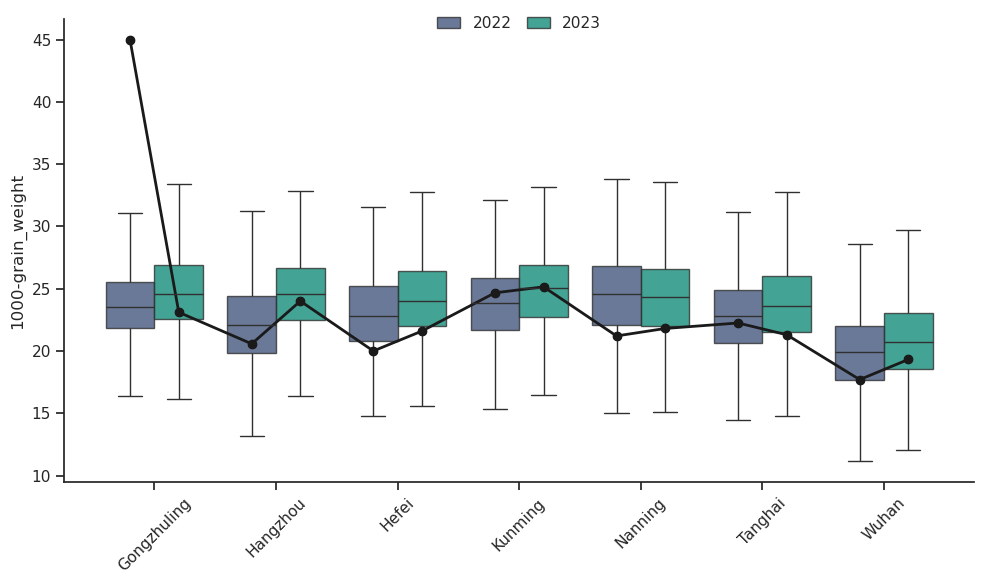


Trait: Yield_per_plant
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D86
最小值: 2.5595
最大值: 56.6667
差值(range): 54.1072
平均值(mean): 15.5382
标准差(std): 15.7413
覆盖环境数: 11
该品种在不同环境(location-year)下的均值如下：
 ID    location  year  Yield_per_plant
D86 Gongzhuling  2022        26.500000
D86 Gongzhuling  2023        24.500000
D86    Hangzhou  2023        15.744000
D86       Hefei  2023        56.666667
D86     Kunming  2022         7.344000
D86     Kunming  2023         9.538000
D86     Nanning  2022         4.930000
D86     Nanning  2023         5.521429
D86     Tanghai  2022         6.486750
D86     Tanghai  2023        11.129750
D86       Wuhan  2023         2.559450


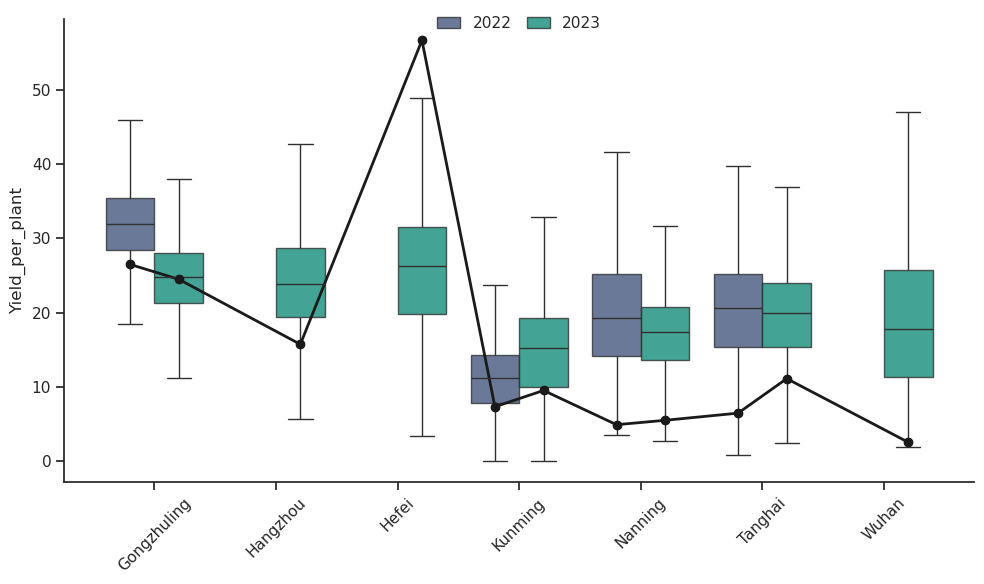


Trait: Heading_date
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D696
最小值: 57.0000
最大值: 140.0000
差值(range): 83.0000
平均值(mean): 81.5000
标准差(std): 26.2261
覆盖环境数: 14
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  Heading_date
D696 Gongzhuling  2022         105.0
D696 Gongzhuling  2023         100.0
D696    Hangzhou  2022          63.0
D696    Hangzhou  2023          66.0
D696       Hefei  2022          67.0
D696       Hefei  2023          62.0
D696     Kunming  2022         122.0
D696     Kunming  2023         140.0
D696     Nanning  2022          57.0
D696     Nanning  2023          57.0
D696     Tanghai  2022          84.0
D696     Tanghai  2023          88.0
D696       Wuhan  2022          62.0
D696       Wuhan  2023          68.0


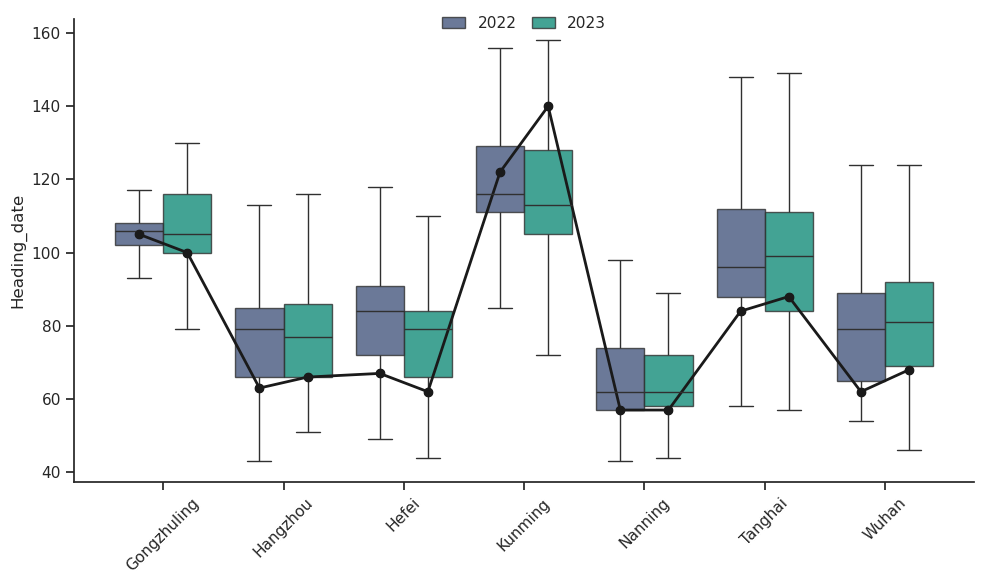


Trait: Plant_height
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D353
最小值: 66.2000
最大值: 127.3000
差值(range): 61.1000
平均值(mean): 94.6505
标准差(std): 15.6480
覆盖环境数: 14
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  Plant_height
D353 Gongzhuling  2022    113.700000
D353 Gongzhuling  2023    107.000000
D353    Hangzhou  2022     91.520000
D353    Hangzhou  2023     88.000000
D353       Hefei  2022     97.300000
D353       Hefei  2023     99.100000
D353     Kunming  2022     66.200000
D353     Kunming  2023     73.500000
D353     Nanning  2022     94.900000
D353     Nanning  2023     91.700000
D353     Tanghai  2022    102.900000
D353     Tanghai  2023    127.300000
D353       Wuhan  2022     90.320000
D353       Wuhan  2023     81.666667


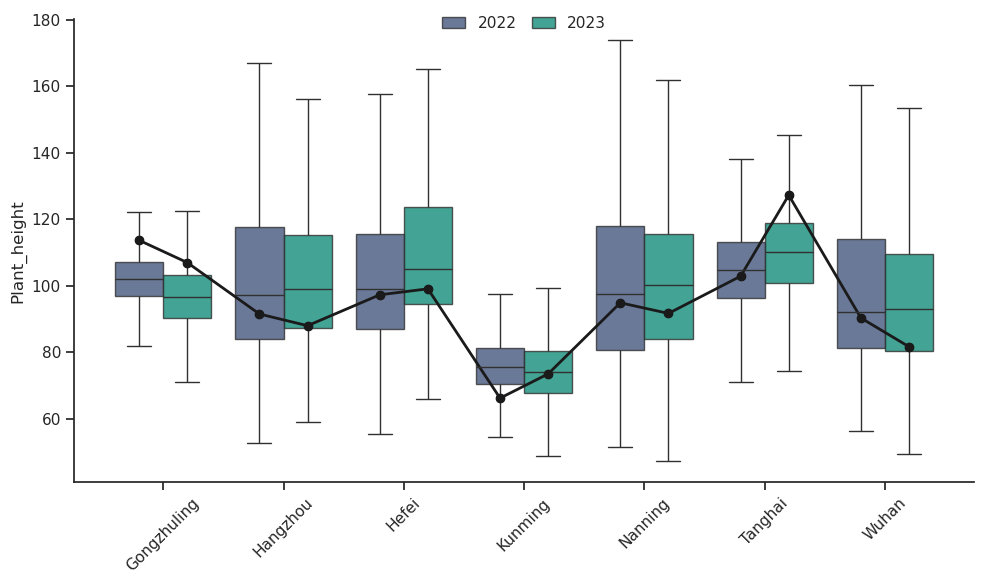


Trait: Grain_length_to_width_ratio
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D191
最小值: 1.9500
最大值: 5.4800
差值(range): 3.5300
平均值(mean): 2.3591
标准差(std): 0.9062
覆盖环境数: 14
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  Grain_length_to_width_ratio
D191 Gongzhuling  2022                     2.051011
D191 Gongzhuling  2023                     1.950000
D191    Hangzhou  2022                     2.174128
D191    Hangzhou  2023                     1.996000
D191       Hefei  2022                     2.093000
D191       Hefei  2023                     2.089000
D191     Kunming  2022                     2.300000
D191     Kunming  2023                     2.100000
D191     Nanning  2022                     2.004494
D191     Nanning  2023                     2.042839
D191     Tanghai  2022                     2.110000
D191     Tanghai  2023                     5.480000


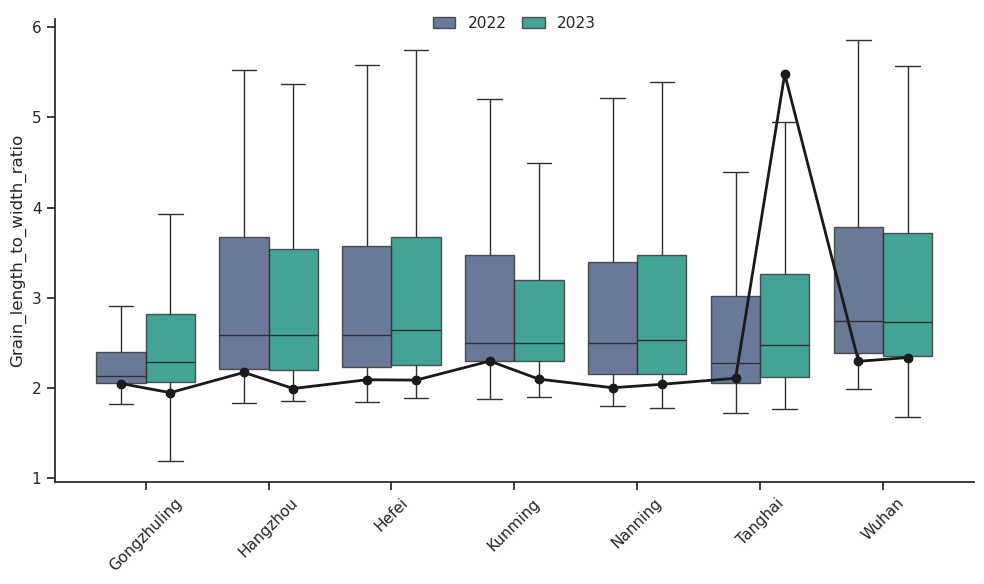


Trait: Tiller_number
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D778
最小值: 5.4000
最大值: 26.5556
差值(range): 21.1556
平均值(mean): 9.7556
标准差(std): 5.4270
覆盖环境数: 13
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  Tiller_number
D778 Gongzhuling  2022       7.500000
D778 Gongzhuling  2023       9.000000
D778    Hangzhou  2022      12.800000
D778    Hangzhou  2023       8.200000
D778       Hefei  2022       7.166667
D778       Hefei  2023      26.555556
D778     Kunming  2022       5.400000
D778     Kunming  2023       6.300000
D778     Nanning  2022       7.100000
D778     Nanning  2023       6.900000
D778     Tanghai  2022      10.700000
D778     Tanghai  2023       9.400000
D778       Wuhan  2023       9.800000


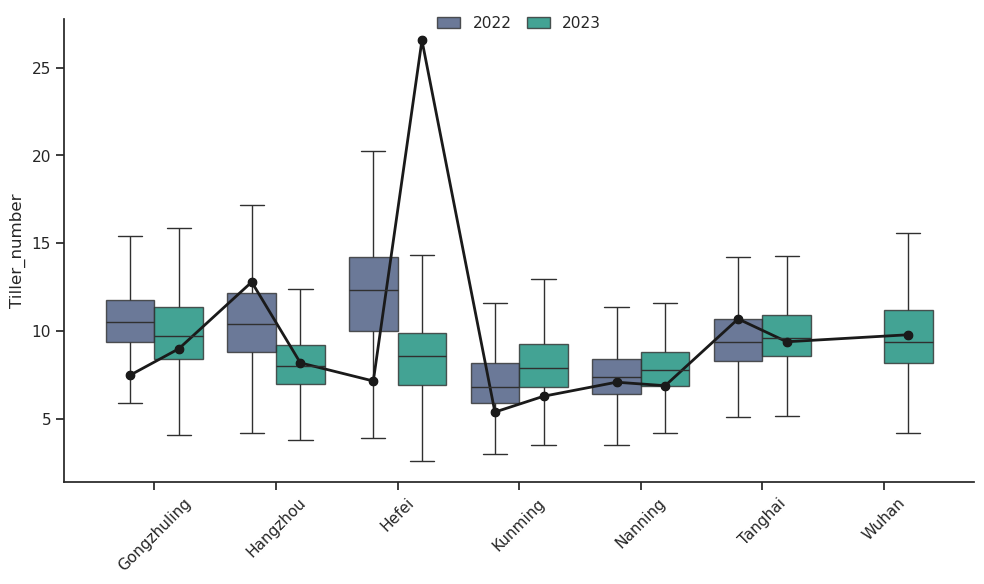


Trait: Grain_per_panicle
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D178
最小值: 117.3000
最大值: 437.7000
差值(range): 320.4000
平均值(mean): 189.4103
标准差(std): 80.2527
覆盖环境数: 13
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  Grain_per_panicle
D178 Gongzhuling  2022         437.700000
D178 Gongzhuling  2023         203.400000
D178    Hangzhou  2022         183.933333
D178    Hangzhou  2023         147.400000
D178       Hefei  2022         184.500000
D178       Hefei  2023         182.300000
D178     Kunming  2022         120.500000
D178     Kunming  2023         117.300000
D178     Nanning  2022         176.200000
D178     Nanning  2023         180.600000
D178     Tanghai  2022         204.300000
D178     Tanghai  2023         190.900000
D178       Wuhan  2023         133.300000


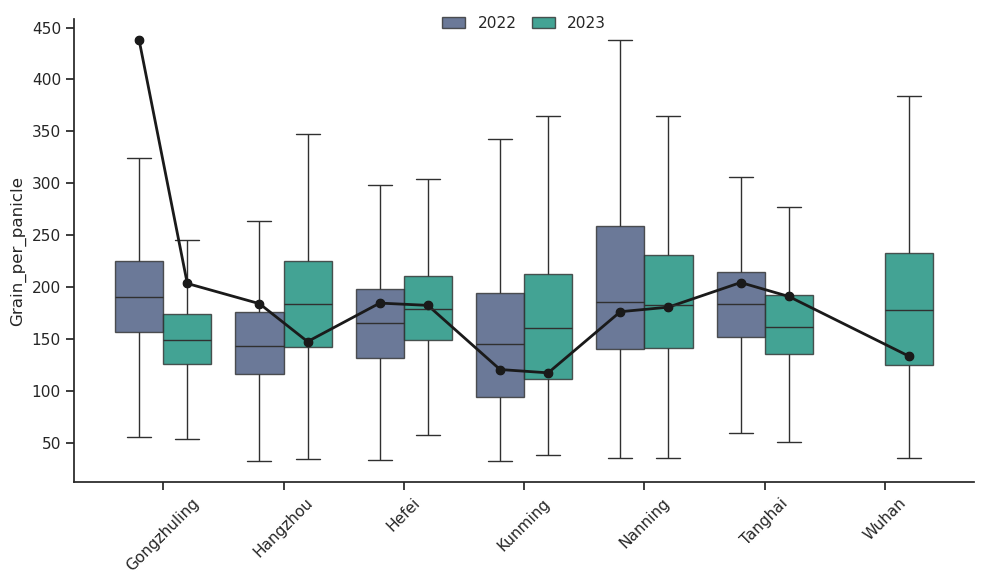


Trait: Seed_set_rate
最终展示的 location: ['Gongzhuling', 'Hangzhou', 'Hefei', 'Kunming', 'Nanning', 'Tanghai', 'Wuhan']
最终展示的 year: [np.int64(2022), np.int64(2023)]
差异最大的品种（且在所有最终展示环境中都有值）: D415
最小值: 14.2947
最大值: 97.1077
差值(range): 82.8130
平均值(mean): 72.0061
标准差(std): 27.9376
覆盖环境数: 11
该品种在不同环境(location-year)下的均值如下：
  ID    location  year  Seed_set_rate
D415 Gongzhuling  2022      97.107692
D415 Gongzhuling  2023      73.083197
D415    Hangzhou  2023      25.276074
D415       Hefei  2023      82.801120
D415     Kunming  2022      95.400000
D415     Kunming  2023      88.019560
D415     Nanning  2022      89.830000
D415     Nanning  2023      89.906233
D415     Tanghai  2022      14.294700
D415     Tanghai  2023      74.168300
D415       Wuhan  2023      62.180000


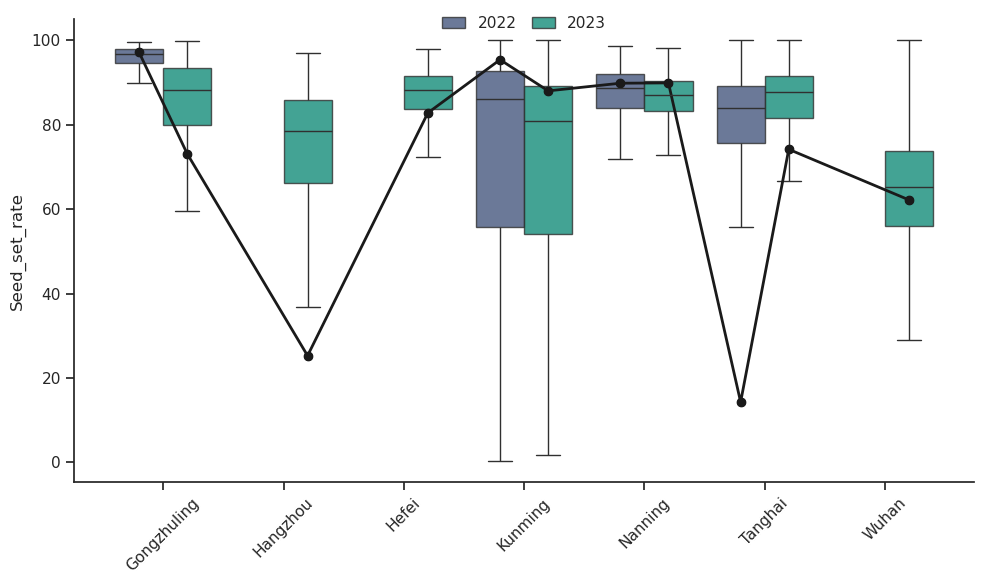

In [3]:
# =========================================================
# 0. 基本设置：Nature-like 风格
# =========================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# =========================
# 1. 基本设置
# =========================
sns.set(style="ticks", font_scale=1)

# =========================
# 4. 单个性状作图
# =========================
def plot_trait_with_top_variety(data, trait, save_path=None):
    tmp = data[["ID", "location", "year", trait]].dropna().copy()

    if tmp.empty:
        print(f"[跳过] {trait}: 没有可用数据")
        return

    # 只保留该 trait 实际有值的 location
    location_order = sorted(tmp["location"].dropna().unique())
    year_order = sorted(tmp["year"].dropna().unique())

    # 如果某个 location 虽然理论上存在，但该 trait 完全无值，则不会进入 tmp，因此自然不会显示
    # 再进一步保证：仅保留至少有一个非空值的 location
    valid_locations = (
        tmp.groupby("location")[trait]
        .apply(lambda x: x.notna().sum() > 0)
    )
    valid_locations = valid_locations[valid_locations].index.tolist()
    location_order = [loc for loc in location_order if loc in valid_locations]

    # palette
    #palette = sns.color_palette("tab10", n_colors=len(year_order))

    # 找满足“所有最终展示环境都有值”的差异最大品种
    top_id, top_stat, top_data, env_pairs = find_most_variable_complete_variety(
        data=tmp,
        trait=trait,
        location_order=location_order,
        year_order=year_order
    )

    print("\n" + "=" * 90)
    print(f"Trait: {trait}")
    print(f"最终展示的 location: {location_order}")
    print(f"最终展示的 year: {year_order}")

    if top_id is None:
        print("没有找到一个品种在该性状最终展示的所有 location × year 环境中都有值，因此不叠加品种趋势线。")
    else:
        print(f"差异最大的品种（且在所有最终展示环境中都有值）: {top_id}")
        print(f"最小值: {top_stat['min']:.4f}")
        print(f"最大值: {top_stat['max']:.4f}")
        print(f"差值(range): {top_stat['range']:.4f}")
        print(f"平均值(mean): {top_stat['mean']:.4f}")
        print(f"标准差(std): {top_stat['std']:.4f}")
        print(f"覆盖环境数: {int(top_stat['count'])}")
        print("该品种在不同环境(location-year)下的均值如下：")
        print(
            top_data[["ID", "location", "year", trait]]
            .sort_values(["location", "year"])
            .to_string(index=False)
        )

    # 作图
    plt.figure(figsize=(10, 6))

    palette = [
    "#3C5488",
    "#00A087",
    "#E64B35",
    "#4DBBD5",
    "#F39B7F",
    "#8491B4"
][:len(year_order)]
    
    ax = sns.boxplot(
        data=tmp,
        x="location",
        y=trait,
        hue="year",
        order=location_order,
        hue_order=year_order,
        palette=palette,
        boxprops=dict(alpha=0.8),
        showfliers=False
    )

    # 叠加关键品种趋势线，但不加入 legend
    if top_id is not None and top_data is not None and not top_data.empty:
        pos_map = get_boxplot_positions(location_order, year_order, width=0.8)

        line_df = top_data.copy()
        line_df["xpos"] = line_df.apply(
            lambda r: pos_map.get((r["location"], r["year"]), np.nan), axis=1
        )
        line_df = line_df.dropna(subset=["xpos"]).sort_values(["location", "year"])
        

        trend_color = "#1A1A1A"
        ax.plot(
            line_df["xpos"],
            line_df[trait],
            marker="o",
            linewidth=2,
            markersize=6,
            color=trend_color,
            label="_nolegend_"
        )

        ax.scatter(
            line_df["xpos"],
            line_df[trait],
            s=30,
            color=trend_color,
            zorder=5,
            label="_nolegend_"
        )

    #ax.set_title(f"{trait} distribution across locations and years", fontsize=14)
    ax.set_xlabel(None)
    ax.set_ylabel(trait)
    plt.xticks(rotation=45)

    # 只保留箱线图 hue(year) 的 legend
    handles, labels = ax.get_legend_handles_labels()
    new_handles = []
    new_labels = []
    for h, l in zip(handles, labels):
        if l != "_nolegend_":
            new_handles.append(h)
            new_labels.append(l)

    # 去重
    uniq = {}
    for h, l in zip(new_handles, new_labels):
        if l not in uniq:
            uniq[l] = h

    ax.legend(
    uniq.values(),
    uniq.keys(),
    #title="year",
        loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(len(uniq), 6),
    frameon=False,
    borderaxespad=0,
         handlelength=1.5,
        columnspacing=1.0
)

    sns.despine(top=True, right=True)

    plt.tight_layout()

    if save_path is not None:
        #plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.savefig(save_path,  format="pdf", bbox_inches='tight', transparent=True)

    plt.show()

#plot_trait_with_top_variety(df, "1000-grain_weight")
# =========================
# 5. 循环画所有性状
# =========================
for trait in traits:
    plot_trait_with_top_variety(df, trait, save_path="../Figure/{}_boxplot.pdf".format(trait))
    plt.close()
